# Child Growth Status Prediction Model Training

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Philimuhire/child-growth-project/blob/master/model/notebooks/train_model.ipynb)

This notebook trains an **XGBoost classifier** to predict child nutritional status using data from the **Rwanda Demographic and Health Survey (RDHS) 2019-2020** dataset.

The model classifies children into one of five nutritional categories:
- **Normal**: adequate nutritional status
- **Stunted**: low height-for-age
- **Wasted**: low weight-for-height
- **Underweight**: low weight-for-age
- **Overweight**: high BMI-for-age

## Running on Google Colab

1. Click the **Open in Colab** badge above.
2. Click **Runtime → Run all**. The notebook downloads the dataset automatically and trains the model end-to-end.
3. *(Optional)* To train on your own DHS file instead, set `USE_OWN_DATASET = True` in the data-loading cell. The notebook will then prompt you to upload an `.xlsx` file.

In [1]:
try:
    import google.colab  # noqa: F401
    _IN_COLAB = True
except ImportError:
    _IN_COLAB = False

if _IN_COLAB:
    %pip install -q xgboost lightgbm openpyxl imbalanced-learn

In [2]:
# Import libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score, roc_auc_score
)

import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import os
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
%matplotlib inline

print('All libraries imported successfully.')


All libraries imported successfully.


## 1. Load and Explore Dataset

The dataset comes from the **Rwanda Demographic and Health Survey (RDHS) 2019-2020 Individual Recode (IR) file**. DHS uses standardized variable codes across all surveys worldwide. The columns we use:

| DHS Code | Meaning | Stored As |
|---|---|---|
| `hw1` | Child's age in months | int (0-59) |
| `b4` | Child's sex | "male" / "female" |
| `hw2` | Child's weight | kg |
| `hw3` | Child's height | cm |
| `v190` | Household wealth quintile | poorest / poorer / middle / richer / richest |
| `v106` | Mother's highest education level | none / primary / secondary / higher |
| `v025` | Residence type | urban / rural |
| `v024` | Province / region | kigali / north / south / east / west |
| `sdistrict` | District (Rwanda-specific) | 30 districts |
| `v116` | Sanitation facility | categorised as improved / unimproved / open_defecation |
| `v113` | Drinking water source | categorised as improved / unimproved |
| `v404` | Currently breastfeeding | yes / no |

The DHS multiplies decimal values by 10 or 100 to store them as integers; the code below reverses this. The full DHS Recode Manual is at https://dhsprogram.com/publications/publication-dhsg4-dhs-questionnaires-and-manuals.cfm


In [3]:
# Load the RDHS dataset (IR file)
#
# Set USE_OWN_DATASET = True to upload your own DHS .xlsx file.

USE_OWN_DATASET = False

import os

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

DATASET_URL = (
    "https://raw.githubusercontent.com/Philimuhire/child-growth-project/"
    "master/model/data/dataset%20for%20ML.xlsx"
)

if USE_OWN_DATASET and IN_COLAB:
    from google.colab import files
    print("Upload your DHS Individual Recode (IR) .xlsx file.")
    uploaded = files.upload()
    if not uploaded:
        raise FileNotFoundError("No file was uploaded.")
    ir_path = next(iter(uploaded.keys()))
elif IN_COLAB:
    import urllib.request
    ir_path = '/content/dataset.xlsx'
    if not os.path.exists(ir_path):
        print("Downloading the bundled DHS dataset...")
        urllib.request.urlretrieve(DATASET_URL, ir_path)
else:
    ir_path = '../data/dataset for ML.xlsx'
    if not os.path.exists(ir_path):
        raise FileNotFoundError(
            f"RDHS dataset not found. Place the file at: {ir_path}"
        )

print(f"Dataset found: {ir_path}")

# Only load the columns we need from the IR file (memory efficient)
ir_cols = ['caseid','bidx','hw1','b4','hw2','hw3','hw70','hw71','hw72','hw73',
           'v190','v106','v025','v024','sdistrict','v116','v113','v404']
ir_available = pd.read_excel(ir_path, engine='openpyxl', nrows=0).columns.tolist()
ir_cols = [c for c in ir_cols if c in ir_available]

raw = pd.read_excel(ir_path, engine='openpyxl', usecols=ir_cols)
print(f"  IR raw shape: {raw.shape}")

# Filter to children with anthropometric measurements
raw = raw[raw['hw1'].notna()].copy()
print(f"  Children with measurements (hw1 not null): {len(raw)}")

# Convert numeric columns
for c in ['hw2','hw3','hw70','hw71','hw72','hw73']:
    raw[c] = pd.to_numeric(raw[c], errors='coerce')

# Build the canonical dataframe
data = pd.DataFrame()
data['age_months'] = raw['hw1'].astype(int)
data['sex']        = raw['b4'].str.strip().str.lower()
data['weight_kg']  = raw['hw2'] / 10.0
data['height_cm']  = raw['hw3'] / 10.0

# Precomputed DHS Z-scores (stored ×100)
data['haz'] = raw['hw70'] / 100.0
data['waz'] = raw['hw71'] / 100.0
data['whz'] = raw['hw72'] / 100.0
data['baz'] = raw['hw73'] / 100.0

# Demographics
data['wealth_index'] = raw['v190'].str.strip().str.lower()
edu_map = {
    'no educa':'none', 'no educat':'none', 'no education':'none',
    'primary':'primary',
    'secondar':'secondary', 'secondary':'secondary',
    'higher':'higher',
}
data['mothers_education'] = raw['v106'].str.strip().str.lower().map(edu_map).fillna('none')
data['residence_type']    = raw['v025'].str.strip().str.lower()
data['region']            = raw['v024'].str.strip().str.lower() if 'v024' in raw.columns else 'unknown'
data['district']          = raw['sdistrict'].str.strip().str.lower() if 'sdistrict' in raw.columns else 'unknown'

def map_sanitation(v):
    v = str(v).strip().lower()
    if v.startswith(('flush','pit latr','ventilat','composti')): return 'improved'
    if v.startswith('no facil') or v.startswith('open') or v == 'bush': return 'open_defecation'
    return 'unimproved'
data['sanitation_type'] = raw['v116'].apply(map_sanitation)

def map_water(v):
    v = str(v).strip().lower()
    for p in ('piped','public t','tube wel','protecte','bottled','rainwate'):
        if v.startswith(p): return 'improved'
    return 'unimproved'
data['water_source'] = raw['v113'].apply(map_water)

# Contextual: currently breastfeeding
if 'v404' in raw.columns:
    bf = raw['v404'].astype(str).str.strip().str.lower()
    data['currently_breastfeeding'] = bf.map({'yes':'yes','no':'no'}).fillna('no')
else:
    data['currently_breastfeeding'] = 'no'

# Drop rows with missing anthropometry / Z-scores
before = len(data)
data = data.dropna(subset=['haz','waz','whz','baz','weight_kg','height_cm']).reset_index(drop=True)
print(f"  After dropping missing: {len(data)} rows (removed {before - len(data)})")

# Clamp Z-scores to WHO convention
for c in ['haz','waz','whz','baz']:
    data[c] = data[c].clip(-6, 6)

print(f"\nFinal dataset shape: {data.shape}")
print(f"\nFirst 5 rows:")
display(data.head())
print(f"\nNull counts:")
print(data.isnull().sum())
print(f"\nCategorical value counts:")
for c in ['sex','wealth_index','mothers_education','residence_type',
          'region','sanitation_type','water_source','currently_breastfeeding']:
    if c in data.columns:
        print(f"  {c}: {dict(data[c].value_counts())}")
print(f"  district: {data['district'].nunique()} unique values (sample: {list(data['district'].unique()[:5])})")


Dataset found: ../data/dataset for ML.xlsx
  IR raw shape: (8092, 18)
  Children with measurements (hw1 not null): 3821
  After dropping missing: 3803 rows (removed 18)

Final dataset shape: (3803, 16)

First 5 rows:


,age_months,sex,weight_kg,height_cm,haz,waz,whz,baz,wealth_index,mothers_education,residence_type,region,district,sanitation_type,water_source,currently_breastfeeding
0,37,male,12.4,89.1,-2.17,-1.38,-0.27,0.06,richer,secondary,rural,kigali,gasabo,improved,improved,no
1,10,female,10.8,69.7,-0.90,1.86,3.00,3.18,richest,secondary,rural,kigali,gasabo,improved,improved,yes
2,53,female,18.2,100.4,-1.20,0.45,1.82,1.70,richest,secondary,rural,kigali,gasabo,improved,improved,yes
3,59,female,14.2,102.9,-1.35,-1.74,-1.40,-1.38,richest,higher,rural,kigali,gasabo,improved,improved,no
4,32,female,10.7,82.8,-2.75,-1.76,-0.16,0.11,richest,primary,rural,kigali,gasabo,improved,improved,no



Null counts:
age_months                 0
sex                        0
weight_kg                  0
height_cm                  0
haz                        0
waz                        0
whz                        0
baz                        0
wealth_index               0
mothers_education          0
residence_type             0
region                     0
district                   0
sanitation_type            0
water_source               0
currently_breastfeeding    0
dtype: int64

Categorical value counts:
  sex: {'male': np.int64(1917), 'female': np.int64(1886)}
  wealth_index: {'poorest': np.int64(915), 'poorer': np.int64(780), 'middle': np.int64(712), 'richer': np.int64(705), 'richest': np.int64(691)}
  mothers_education: {'primary': np.int64(2480), 'secondary': np.int64(695), 'none': np.int64(452), 'higher': np.int64(176)}
  residence_type: {'rural': np.int64(3016), 'urban': np.int64(787)}
  region: {'west': np.int64(973), 'east': np.int64(917), 'south': np.int64(875), 'north

## 2. Z-Scores (Precomputed by DHS)

The four WHO Z-scores (WAZ, HAZ, WHZ, BAZ) come precomputed from the DHS dataset (`hw70`-`hw73`, divided by 100). This section inspects their distributions to confirm the data looks healthy before using them as model features and to derive the target labels in the next section.


Z-score summary:


,waz,haz,whz,baz
count,3803.000000,3803.000000,3803.000000,3803.000000
mean,-0.579540,-1.512984,0.400126,0.535693
std,1.008609,1.166522,1.005579,1.020109
min,-5.410000,-5.900000,-4.660000,-4.750000
25%,-1.220000,-2.280000,-0.250000,-0.120000
50%,-0.570000,-1.540000,0.380000,0.530000
75%,0.050000,-0.740000,1.055000,1.185000
max,3.360000,3.950000,4.300000,4.440000


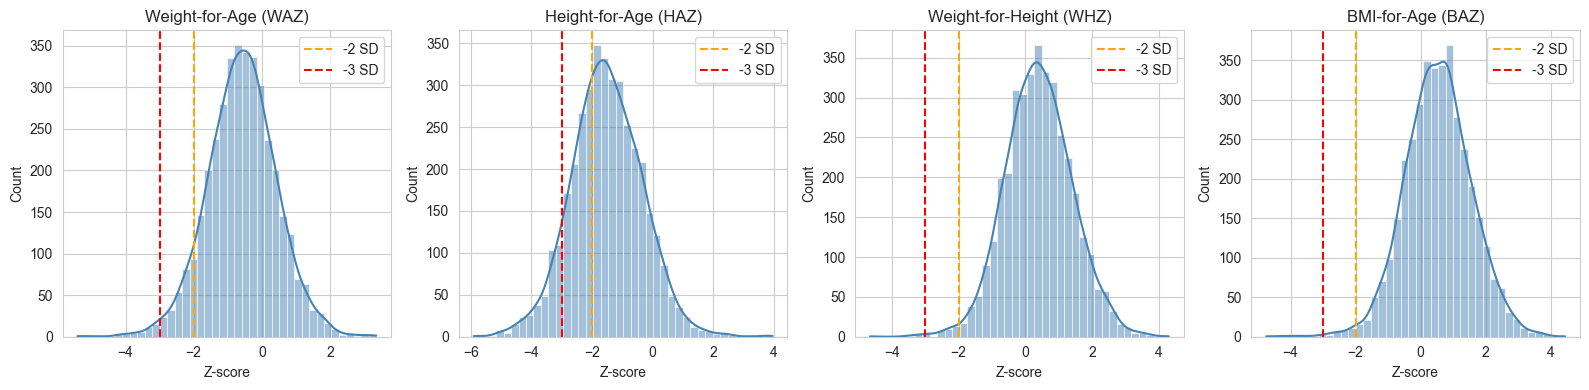

In [4]:
print("Z-score summary:")
display(data[['waz', 'haz', 'whz', 'baz']].describe())

# Visualize Z-score distributions
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col, title in zip(axes, ['waz', 'haz', 'whz', 'baz'],
                            ['Weight-for-Age', 'Height-for-Age', 'Weight-for-Height', 'BMI-for-Age']):
    sns.histplot(data[col], bins=40, kde=True, ax=ax, color='steelblue')
    ax.axvline(-2, color='orange', linestyle='--', label='-2 SD')
    ax.axvline(-3, color='red', linestyle='--', label='-3 SD')
    ax.set_title(f'{title} ({col.upper()})')
    ax.set_xlabel('Z-score')
    ax.legend()
plt.tight_layout()
plt.show()


## 3. Create Target Labels

Convert the four Z-scores into a single nutritional status label per child using WHO thresholds with a priority order (wasted > underweight > stunted > overweight > normal). The model will be trained to predict this single class.


Nutritional Status Distribution:
status
normal         2331
stunted        1013
underweight     252
overweight      165
wasted           42
Name: count, dtype: int64

Percentages:
status
normal         61.29
stunted        26.64
underweight     6.63
overweight      4.34
wasted          1.10
Name: proportion, dtype: float64


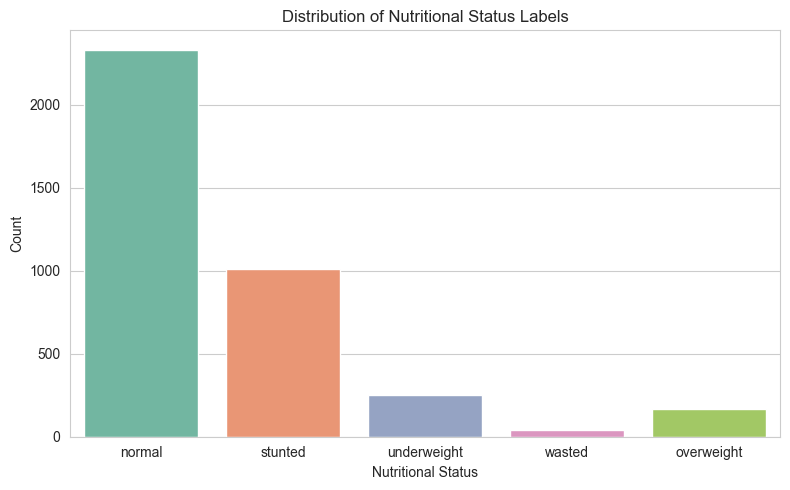

In [5]:
# Assign a single nutritional status label using WHO thresholds
# Priority order: wasted > underweight > stunted > overweight > normal
def classify_status(row):
    if row['whz'] < -2:
        return 'wasted'
    elif row['waz'] < -2:
        return 'underweight'
    elif row['haz'] < -2:
        return 'stunted'
    elif row['baz'] > 2:
        return 'overweight'
    else:
        return 'normal'


# Apply the function to every row
data['status'] = data.apply(classify_status, axis=1)

# Show class distribution
print("Nutritional Status Distribution:")
print(data['status'].value_counts())
print(f"\nPercentages:")
print(data['status'].value_counts(normalize=True).round(4) * 100)

# Plot the distribution
fig, ax = plt.subplots(figsize=(8, 5))
order = ['normal', 'stunted', 'underweight', 'wasted', 'overweight']
sns.countplot(data=data, x='status', order=order, palette='Set2', ax=ax)
ax.set_title('Distribution of Nutritional Status Labels')
ax.set_xlabel('Nutritional Status')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()


## 4. Feature Engineering and Encoding

Convert all categorical variables (sex, wealth quintile, region, district, etc.) into integer codes the model can consume, then scale the resulting feature matrix so every column has zero mean and unit variance. The encoding maps are saved to disk so the backend uses identical encoding at inference time.


In [6]:
# Categorical encoding maps (kept in sync with backend/app/services/ml_service.py)
CATEGORICAL_ENCODINGS = {
    'sex': {'male': 0, 'female': 1},
    'wealth_index': {'poorest': 0, 'poorer': 1, 'middle': 2, 'richer': 3, 'richest': 4},
    'mothers_education': {'none': 0, 'primary': 1, 'secondary': 2, 'higher': 3},
    'residence_type': {'urban': 0, 'rural': 1},
    'region': {'kigali': 0, 'south': 1, 'north': 2, 'east': 3, 'west': 4},
    'sanitation_type': {'improved': 0, 'unimproved': 1, 'open_defecation': 2},
    'water_source': {'improved': 0, 'unimproved': 1},
    'currently_breastfeeding': {'yes': 1, 'no': 0},
}

# District has 30 categories (Rwandan districts). Build a stable label-encoded map
# from the distinct values present in the training data, alphabetically ordered.
DISTRICT_ENCODING = {d: i for i, d in enumerate(sorted(data['district'].dropna().unique()))}
CATEGORICAL_ENCODINGS['district'] = DISTRICT_ENCODING
print(f"District encoding: {len(DISTRICT_ENCODING)} unique districts")

# Apply categorical encodings
for col, mapping in CATEGORICAL_ENCODINGS.items():
    if col in data.columns:
        data[col] = data[col].map(mapping)

# Drop rows where encoding produced NaN (unexpected category)
before = len(data)
data = data.dropna(subset=list(CATEGORICAL_ENCODINGS.keys()))
if len(data) < before:
    print(f"Dropped {before - len(data)} rows with unmapped categorical values")

# 12 model features (4 anthropometric + 7 demographic/geo + 1 contextual).
# The four WHO Z-scores (waz, haz, whz, baz) remain in `data` for labelling only.
FEATURE_COLUMNS = [
    # Anthropometric
    'age_months', 'sex', 'weight_kg', 'height_cm',
    # Demographic / socioeconomic / geographic
    'wealth_index', 'mothers_education', 'residence_type',
    'region', 'district',
    'sanitation_type', 'water_source',
    # Contextual
    'currently_breastfeeding',
]

# Prepare features and target
X = data[FEATURE_COLUMNS].copy()
y = data['status'].copy()

# Encode target labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
print(f"Class mapping: {dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))}")

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"\nFeature matrix shape: {X_scaled.shape}")
print(f"Number of features: {len(FEATURE_COLUMNS)}")
print(f"Features: {FEATURE_COLUMNS}")
print(f"Classes: {list(label_encoder.classes_)}")


District encoding: 30 unique districts
Class mapping: {'normal': np.int64(0), 'overweight': np.int64(1), 'stunted': np.int64(2), 'underweight': np.int64(3), 'wasted': np.int64(4)}

Feature matrix shape: (3803, 12)
Number of features: 12
Features: ['age_months', 'sex', 'weight_kg', 'height_cm', 'wealth_index', 'mothers_education', 'residence_type', 'region', 'district', 'sanitation_type', 'water_source', 'currently_breastfeeding']
Classes: ['normal', 'overweight', 'stunted', 'underweight', 'wasted']


## 5. Train/Test Split

Split the dataset into 80% training and 20% test. The split is stratified on the target class so rare categories (e.g. wasted) end up in both sides — without this, the test set might contain none of them.


In [7]:
# Stratified 80/20 train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded,
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size:     {X_test.shape[0]}")
print(f"\nTraining class distribution:")
for cls, name in enumerate(label_encoder.classes_):
    count = (y_train == cls).sum()
    print(f"  {name:12s}: {count} ({count/len(y_train)*100:.1f}%)")


Training set size: 3042
Test set size:     761

Training class distribution:
  normal      : 1864 (61.3%)
  overweight  : 132 (4.3%)
  stunted     : 810 (26.6%)
  underweight : 202 (6.6%)
  wasted      : 34 (1.1%)


## 6. Handle Class Imbalance

The dataset is dominated by "normal" children (~61%) while "wasted" is ~1%. Without rebalancing, the model would just predict "normal" everywhere. We compute **softened** inverse-frequency sample weights (exponent 0.6) so the minority classes contribute meaningfully to the loss without the rare *wasted* class receiving an extreme ~18× weight that would destabilise training and collapse overall accuracy.


In [8]:
# Compute softened inverse-frequency sample weights to handle class imbalance
from collections import Counter

class_counts = Counter(y_train)
total = len(y_train)

# Softening exponent: full inverse frequency (exponent 1.0) gives the rare
# 'wasted' class a ~18x weight, which destabilises training and tanks overall
# accuracy. An exponent of 0.6 still lifts the minority classes while keeping
# the model stable.
WEIGHT_EXPONENT = 0.6
sample_weights = np.array(
    [(total / (len(class_counts) * class_counts[y])) ** WEIGHT_EXPONENT for y in y_train]
)

print(f"Class weights (softened inverse frequency, exponent {WEIGHT_EXPONENT}):")
for cls in sorted(class_counts.keys()):
    weight = (total / (len(class_counts) * class_counts[cls])) ** WEIGHT_EXPONENT
    print(f"  {label_encoder.classes_[cls]:12s}: {weight:.4f}")

# SMOTE alternative (commented out):
# from imblearn.over_sampling import SMOTE
# X_train_resampled, y_train_resampled = SMOTE(random_state=42).fit_resample(X_train, y_train)

Class weights (softened inverse frequency, exponent 0.6):
  normal      : 0.5108
  overweight  : 2.5013
  stunted     : 0.8422
  underweight : 1.9378
  wasted      : 5.6445


## 7. Model Training, Comparison, and Selection

Train three tree-based models on the same train/test split, compare them on the same metrics, and pick the production model.

### Models compared

| Model | Library |
|---|---|
| **LightGBM** | `lightgbm` (Microsoft) |
| **Random Forest** | `sklearn.ensemble` |
| **XGBoost** | `xgboost` |

### Metrics collected per model

| Variable | Metric | Meaning |
|---|---|---|
| `acc` | Accuracy | Fraction of predictions that exactly match the true label |
| `f1_macro` | Macro F1 | Average per-class F1, treating each class equally: fair to rare classes |
| `f1_weighted` | Weighted F1 | Average per-class F1, weighted by class size |
| `auc` | ROC-AUC | How well the model ranks correct examples above incorrect ones (One-vs-Rest) |
| `f1_per_class` | Per-class F1 | F1 broken down per nutritional status |
| `train_time` | Training time (s) | Time to fit the model |

### Selection criterion

The winner is picked by combining three scores in order of priority:

1. **Accuracy**: primary score (overall correctness)
2. **Macro F1**: first tiebreaker (treats each class equally, robust to imbalance)
3. **ROC-AUC**: second tiebreaker (how well the model ranks correct vs incorrect)


Testing LightGBM...
Train Accuracy: 0.9504  |  Test Accuracy: 0.8673
Train Macro F1: 0.9493  |  Test Macro F1: 0.7569
Train Weighted F1: 0.9503  |  Test Weighted F1: 0.8660
ROC-AUC:     0.9579
Train time:  3.02s

Testing Random Forest...
Train Accuracy: 0.8393  |  Test Accuracy: 0.7424
Train Macro F1: 0.8138  |  Test Macro F1: 0.4616
Train Weighted F1: 0.8390  |  Test Weighted F1: 0.7279
ROC-AUC:     0.8708
Train time:  0.75s

Testing XGBoost...
Train Accuracy: 0.9675  |  Test Accuracy: 0.8778
Train Macro F1: 0.9738  |  Test Macro F1: 0.7859
Train Weighted F1: 0.9674  |  Test Weighted F1: 0.8762
ROC-AUC:     0.9624
Train time:  5.74s

OVERALL COMPARISON


,Train Accuracy,Train Macro F1,Train Weighted F1,Accuracy,Macro F1,Weighted F1,ROC-AUC,Train Time (s)
Model,,,,,,,,
LightGBM,0.9504,0.9493,0.9503,0.8673,0.7569,0.8660,0.9579,3.02
Random Forest,0.8393,0.8138,0.8390,0.7424,0.4616,0.7279,0.8708,0.75
XGBoost,0.9675,0.9738,0.9674,0.8778,0.7859,0.8762,0.9624,5.74



PER-CLASS F1 SCORE


,normal,overweight,stunted,underweight,wasted
Model,,,,,
LightGBM,0.918,0.623,0.812,0.800,0.632
Random Forest,0.824,0.279,0.653,0.553,0.000
XGBoost,0.920,0.633,0.834,0.828,0.714


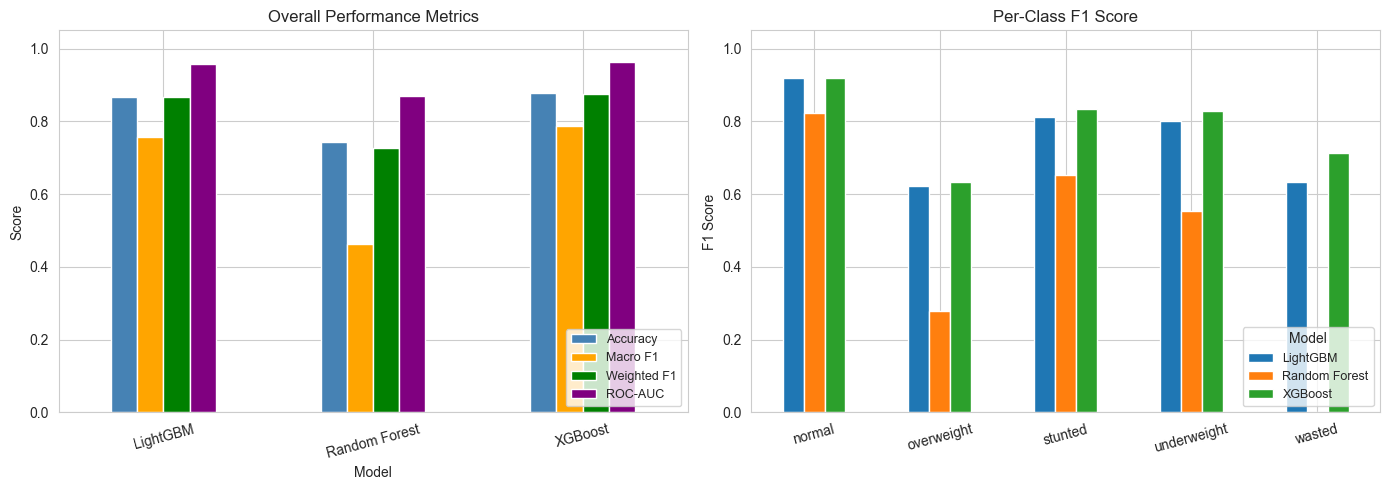


MODEL SELECTION
Selected model: XGBoost
  Macro F1:    0.7859
  ROC-AUC:     0.9624
  Accuracy:    0.8778
  Train time:  5.74s

Selection criterion: highest Macro F1, with ROC-AUC and Accuracy as tiebreakers.
'XGBoost' will be saved as the production artifact and served by
the FastAPI backend.

DETAILED EVALUATION: XGBoost

Classification report for XGBoost:
              precision    recall  f1-score   support

      normal       0.91      0.93      0.92       467
  overweight       0.70      0.58      0.63        33
     stunted       0.84      0.83      0.83       203
 underweight       0.84      0.82      0.83        50
      wasted       0.83      0.62      0.71         8

    accuracy                           0.88       761
   macro avg       0.82      0.76      0.79       761
weighted avg       0.88      0.88      0.88       761



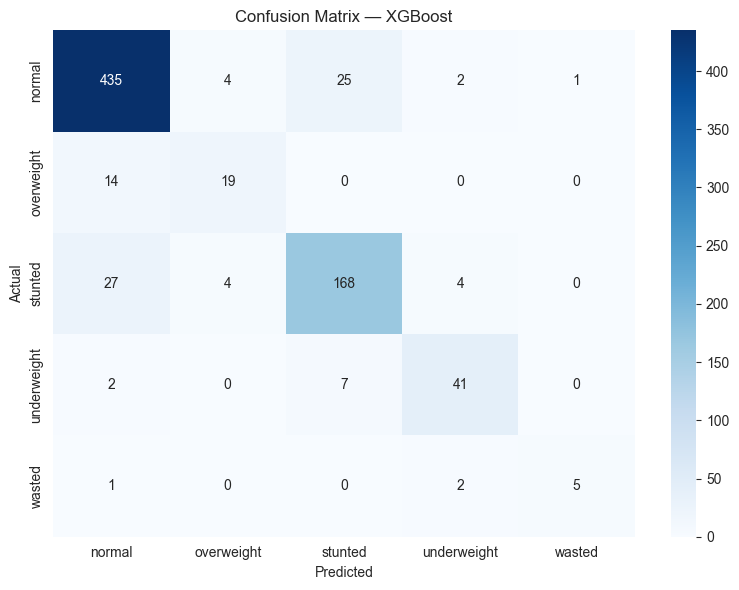


Feature importance values:
  weight_kg                : 0.188746
  age_months               : 0.154391
  height_cm                : 0.141152
  wealth_index             : 0.078021
  sex                      : 0.070723
  residence_type           : 0.060555
  region                   : 0.058029
  mothers_education        : 0.054448
  district                 : 0.052340
  currently_breastfeeding  : 0.051319
  water_source             : 0.050534
  sanitation_type          : 0.039742


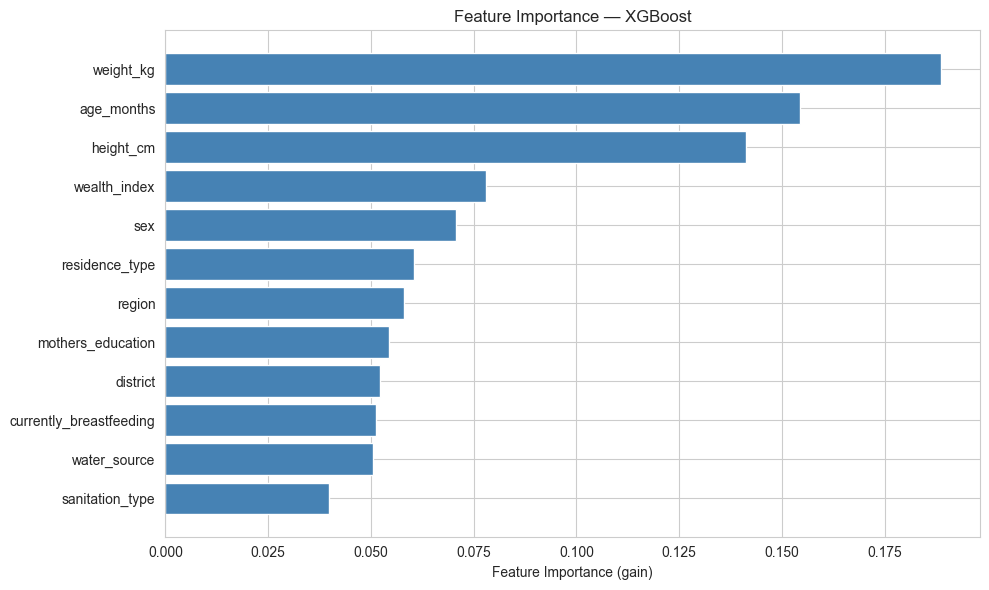

In [9]:
# Train and evaluate three candidate models on the same train/test split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    f1_score, accuracy_score, roc_auc_score,
    classification_report, confusion_matrix,
)
import lightgbm as lgb
import xgboost as xgb
import time

# All three models are regularised (shallow trees, subsampling, L2) for a
# realistic train-vs-test gap.
# importance_type='gain' reports actual loss reduction rather than split count.
candidates = {
    'LightGBM': lgb.LGBMClassifier(
        n_estimators=200, max_depth=4, num_leaves=15, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.7, min_child_samples=20, reg_lambda=1.5,
        random_state=42, n_jobs=-1, verbose=-1,
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=8, min_samples_leaf=5,
        random_state=42, n_jobs=-1,
    ),
    'XGBoost': xgb.XGBClassifier(
        objective='multi:softprob', num_class=5, eval_metric='mlogloss',
        max_depth=5, learning_rate=0.04, n_estimators=300,
        subsample=0.8, colsample_bytree=0.7,
        min_child_weight=3, reg_lambda=2.0,
        importance_type='gain', random_state=42,
    ),
}

# Train each candidate, collect metrics + the trained model
results = []
trained_models = {}

for name, mdl in candidates.items():
    print(f"\n{'='*70}")
    print(f"Testing {name}...")
    print(f"{'='*70}")

    t0 = time.time()
    mdl.fit(X_train, y_train, sample_weight=sample_weights)
    train_time = time.time() - t0

    # Training-set performance (train-vs-test comparison / overfitting check)
    train_pred = mdl.predict(X_train)
    train_acc = accuracy_score(y_train, train_pred)
    train_f1_macro = f1_score(y_train, train_pred, average='macro')
    train_f1_weighted = f1_score(y_train, train_pred, average='weighted')

    y_pred = mdl.predict(X_test)
    y_proba = mdl.predict_proba(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro')
    f1_weighted = f1_score(y_test, y_pred, average='weighted')
    auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='weighted')
    f1_per_class = f1_score(y_test, y_pred, average=None)

    results.append({
        'Model': name,
        'Train Accuracy': train_acc,
        'Train Macro F1': train_f1_macro,
        'Train Weighted F1': train_f1_weighted,
        'Accuracy': acc,
        'Macro F1': f1_macro,
        'Weighted F1': f1_weighted,
        'ROC-AUC': auc,
        'Train Time (s)': round(train_time, 2),
        'per_class_f1': f1_per_class,
    })
    trained_models[name] = mdl

    print(f"Train Accuracy: {train_acc:.4f}  |  Test Accuracy: {acc:.4f}")
    print(f"Train Macro F1: {train_f1_macro:.4f}  |  Test Macro F1: {f1_macro:.4f}")
    print(f"Train Weighted F1: {train_f1_weighted:.4f}  |  Test Weighted F1: {f1_weighted:.4f}")
    print(f"ROC-AUC:     {auc:.4f}")
    print(f"Train time:  {train_time:.2f}s")

# ---------- Comparison tables ----------
print("\n" + "="*70)
print("OVERALL COMPARISON")
print("="*70)

results_df = pd.DataFrame([
    {k: v for k, v in r.items() if k != 'per_class_f1'} for r in results
]).set_index('Model')
for col in ['Train Accuracy', 'Train Macro F1', 'Train Weighted F1', 'Accuracy', 'Macro F1', 'Weighted F1', 'ROC-AUC']:
    results_df[col] = results_df[col].astype(float).round(4)
display(results_df)

print("\n" + "="*70)
print("PER-CLASS F1 SCORE")
print("="*70)
per_class_df = pd.DataFrame(
    [[r['Model']] + [round(v, 3) for v in r['per_class_f1']] for r in results],
    columns=['Model'] + list(label_encoder.classes_),
).set_index('Model')
display(per_class_df)

# ---------- Visual comparison ----------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

results_df[['Accuracy', 'Macro F1', 'Weighted F1', 'ROC-AUC']].plot(
    kind='bar', ax=axes[0],
    color=['steelblue', 'orange', 'green', 'purple'],
)
axes[0].set_title('Overall Performance Metrics')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1.05)
axes[0].legend(loc='lower right', fontsize=9)
axes[0].tick_params(axis='x', rotation=15)

per_class_df.T.plot(kind='bar', ax=axes[1])
axes[1].set_title('Per-Class F1 Score')
axes[1].set_ylabel('F1 Score')
axes[1].set_ylim(0, 1.05)
axes[1].set_xlabel('')
axes[1].legend(title='Model', loc='lower right', fontsize=9)
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

# ---------- Pick the winner ----------
# Sort by Macro F1, then ROC-AUC, then Accuracy as tiebreakers (all descending).
sorted_results = sorted(
    results,
    key=lambda r: (-r['Macro F1'], -r['ROC-AUC'], -r['Accuracy']),
)
best = sorted_results[0]
best_name = best['Model']
model = trained_models[best_name]   # production model

print("\n" + "="*70)
print("MODEL SELECTION")
print("="*70)
print(f"Selected model: {best_name}")
print(f"  Macro F1:    {best['Macro F1']:.4f}")
print(f"  ROC-AUC:     {best['ROC-AUC']:.4f}")
print(f"  Accuracy:    {best['Accuracy']:.4f}")
print(f"  Train time:  {best['Train Time (s)']}s")
print()
print("Selection criterion: highest Macro F1, with ROC-AUC and Accuracy as tiebreakers.")
print(f"'{best_name}' will be saved as the production artifact and served by")
print("the FastAPI backend.")

# ---------- Detailed evaluation of the chosen model ----------
print("\n" + "="*70)
print(f"DETAILED EVALUATION: {best_name}")
print("="*70)

y_pred = model.predict(X_test)
y_probas = model.predict_proba(X_test)
accuracy = accuracy_score(y_test, y_pred)
class_report_dict = classification_report(
    y_test, y_pred, target_names=label_encoder.classes_, output_dict=True,
)

print(f"\nClassification report for {best_name}:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_,
    ax=ax,
)
ax.set_title(f'Confusion Matrix — {best_name}')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

# Feature importance (if available)
if hasattr(model, 'feature_importances_'):
    importances = model.feature_importances_
    fi_df = pd.DataFrame({
        'feature': FEATURE_COLUMNS,
        'importance': importances,
    }).sort_values('importance', ascending=False)

    print("\nFeature importance values:")
    for _, row in fi_df.iterrows():
        print(f"  {row['feature']:25s}: {row['importance']:.6f}")

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(fi_df['feature'][::-1], fi_df['importance'][::-1], color='steelblue')
    ax.set_xlabel('Feature Importance (gain)')
    ax.set_title(f'Feature Importance — {best_name}')
    plt.tight_layout()
    plt.show()


## 8. Learning Curve

Plot training vs cross-validation accuracy as the training set grows. A trustworthy model shows the two curves **converging with a small remaining gap** — evidence of genuine learning.

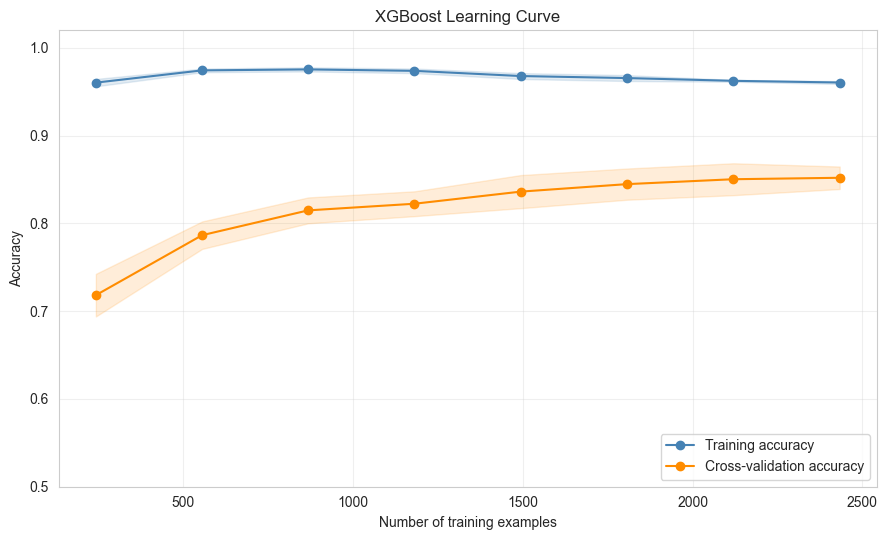

Cross-validation accuracy at full training size: 0.852
Final train - CV accuracy gap: 0.109 (a small positive gap is healthy)


In [10]:
# Learning curve: training vs cross-validation accuracy as the data grows.
from sklearn.base import clone
from sklearn.model_selection import learning_curve, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
train_sizes, train_scores, val_scores = learning_curve(
    clone(model), X_train, y_train,
    cv=cv, scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1, shuffle=True, random_state=42,
)
train_mean, train_std = train_scores.mean(axis=1), train_scores.std(axis=1)
val_mean, val_std = val_scores.mean(axis=1), val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(train_sizes, train_mean, 'o-', color='steelblue', label='Training accuracy')
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                alpha=0.15, color='steelblue')
ax.plot(train_sizes, val_mean, 'o-', color='darkorange', label='Cross-validation accuracy')
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                alpha=0.15, color='darkorange')
ax.set_xlabel('Number of training examples')
ax.set_ylabel('Accuracy')
ax.set_title(f'{best_name} Learning Curve')
ax.set_ylim(0.5, 1.02)
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('learning_curve.png', dpi=110)
plt.show()

print(f"Cross-validation accuracy at full training size: {val_mean[-1]:.3f}")
print(f"Final train - CV accuracy gap: {train_mean[-1] - val_mean[-1]:.3f} "
      "(a small positive gap is healthy)")

## 9. Save Model Artifacts

Persist the trained model and its preprocessing artifacts (scaler, label encoder, feature columns, district encodings) to disk. The same files are also copied to `backend/app/ml_artifacts/` so the FastAPI server picks them up on startup.


In [11]:
import os

artifacts_dir = '../artifacts' if not IN_COLAB else 'artifacts'
os.makedirs(artifacts_dir, exist_ok=True)

# Save model + preprocessing artifacts
joblib.dump(model, os.path.join(artifacts_dir, 'xgb_model.joblib'))
joblib.dump(label_encoder, os.path.join(artifacts_dir, 'label_encoder.joblib'))
joblib.dump(scaler, os.path.join(artifacts_dir, 'scaler.joblib'))
joblib.dump(FEATURE_COLUMNS, os.path.join(artifacts_dir, 'feature_columns.joblib'))
joblib.dump(CATEGORICAL_ENCODINGS, os.path.join(artifacts_dir, 'categorical_encodings.joblib'))

# Mirror artifacts into the FastAPI backend folder when running inside the repo
backend_artifacts = '../../backend/app/ml_artifacts'
if not IN_COLAB and os.path.isdir(os.path.dirname(backend_artifacts)):
    os.makedirs(backend_artifacts, exist_ok=True)
    for fname in ['xgb_model.joblib','label_encoder.joblib','scaler.joblib',
                  'feature_columns.joblib','categorical_encodings.joblib']:
        joblib.dump(
            joblib.load(os.path.join(artifacts_dir, fname)),
            os.path.join(backend_artifacts, fname)
        )
    print(f"Artifacts also copied to backend at {backend_artifacts}")

# Save training report
report = {
    'accuracy': float(accuracy),
    'classification_report': class_report_dict,
    'feature_columns': FEATURE_COLUMNS,
    'class_names': list(label_encoder.classes_),
    'n_train': int(len(X_train)),
    'n_test': int(len(X_test)),
    'categorical_encodings': {k: v for k, v in CATEGORICAL_ENCODINGS.items() if k != 'district'},
    'n_districts': len(CATEGORICAL_ENCODINGS.get('district', {})),
}
with open(os.path.join(artifacts_dir, 'training_report.json'), 'w') as f:
    json.dump(report, f, indent=2)

print("All artifacts saved successfully.")
print(f"Model saved to {artifacts_dir}")

if IN_COLAB:
    import shutil
    zip_path = shutil.make_archive('artifacts', 'zip', artifacts_dir)
    from google.colab import files
    print(f"\nDownloading {zip_path} ...")
    files.download(zip_path)


Artifacts also copied to backend at ../../backend/app/ml_artifacts
All artifacts saved successfully.
Model saved to ../artifacts


## 10. Test Inference

Reload the saved artifacts from disk and run a few predictions to confirm everything serialized correctly before handing the files to the backend.


In [12]:
# Reload artifacts and verify inference
loaded_model   = joblib.load(os.path.join(artifacts_dir, 'xgb_model.joblib'))
loaded_encoder = joblib.load(os.path.join(artifacts_dir, 'label_encoder.joblib'))
loaded_scaler  = joblib.load(os.path.join(artifacts_dir, 'scaler.joblib'))

# Run predictions on 5 test samples
sample = X_test[:5]
preds  = loaded_model.predict(sample)
probas = loaded_model.predict_proba(sample)

print("Inference test with 5 samples from the test set:\n")
for i in range(5):
    predicted_label = loaded_encoder.inverse_transform([preds[i]])[0]
    confidence      = probas[i][preds[i]]
    actual_label    = loaded_encoder.inverse_transform([y_test[i]])[0]
    ok = 'OK' if predicted_label == actual_label else 'MISS'
    print(f"  Sample {i+1}: Predicted={predicted_label:12s} "
          f"Confidence={confidence:5.2%}  Actual={actual_label:12s}  [{ok}]")

print("\nInference test passed! Model is ready for deployment.")


Inference test with 5 samples from the test set:

  Sample 1: Predicted=normal       Confidence=76.90%  Actual=normal        [OK]
  Sample 2: Predicted=normal       Confidence=97.50%  Actual=normal        [OK]
  Sample 3: Predicted=underweight  Confidence=77.18%  Actual=underweight   [OK]
  Sample 4: Predicted=normal       Confidence=67.54%  Actual=normal        [OK]
  Sample 5: Predicted=normal       Confidence=70.98%  Actual=normal        [OK]

Inference test passed! Model is ready for deployment.
